# Imports

In [1]:
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelBinarizer

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.utils import plot_model, to_categorical
from tensorflow.keras.optimizers import Adam

# Load dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalise data in the range [-1, 1]
X_train = X_train/255
X_test = X_test/255

# Flatten images
X_train_flatten = X_train.reshape(len(X_train), 28*28)
X_test_flatten = X_test.reshape(len(X_test), 28*28)

# One hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [3]:
print("Train X dataset shape: ", np.shape(X_train))
print("Train X flatten dataset shape: ", np.shape(X_train_flatten))
print("Train y dataset shape: ", np.shape(y_train))
print("Test X dataset shape: ", np.shape(X_test))
print("Test X flatten dataset shape: ", np.shape(X_test_flatten))
print("Test y dataset shape: ", np.shape(y_test))

Train X dataset shape:  (60000, 28, 28)
Train X flatten dataset shape:  (60000, 784)
Train y dataset shape:  (60000, 10)
Test X dataset shape:  (10000, 28, 28)
Test X flatten dataset shape:  (10000, 784)
Test y dataset shape:  (10000, 10)


In [4]:
def show_examples(X, y_real, y_pred, num=1):
    fig, ax = plt.subplots(num, 5, figsize=[25, 5 * num])
    plt.subplots_adjust(hspace=0.5) 

    for i, (img, ax) in enumerate(zip(X[:5*num], ax.flatten())):
        ax.imshow(img, cmap='Greys')
        ax.set_title('y real: ' + str(y_real[i]) +
                        '\ny predicted: ' + str(y_pred[i]))
    plt.show()

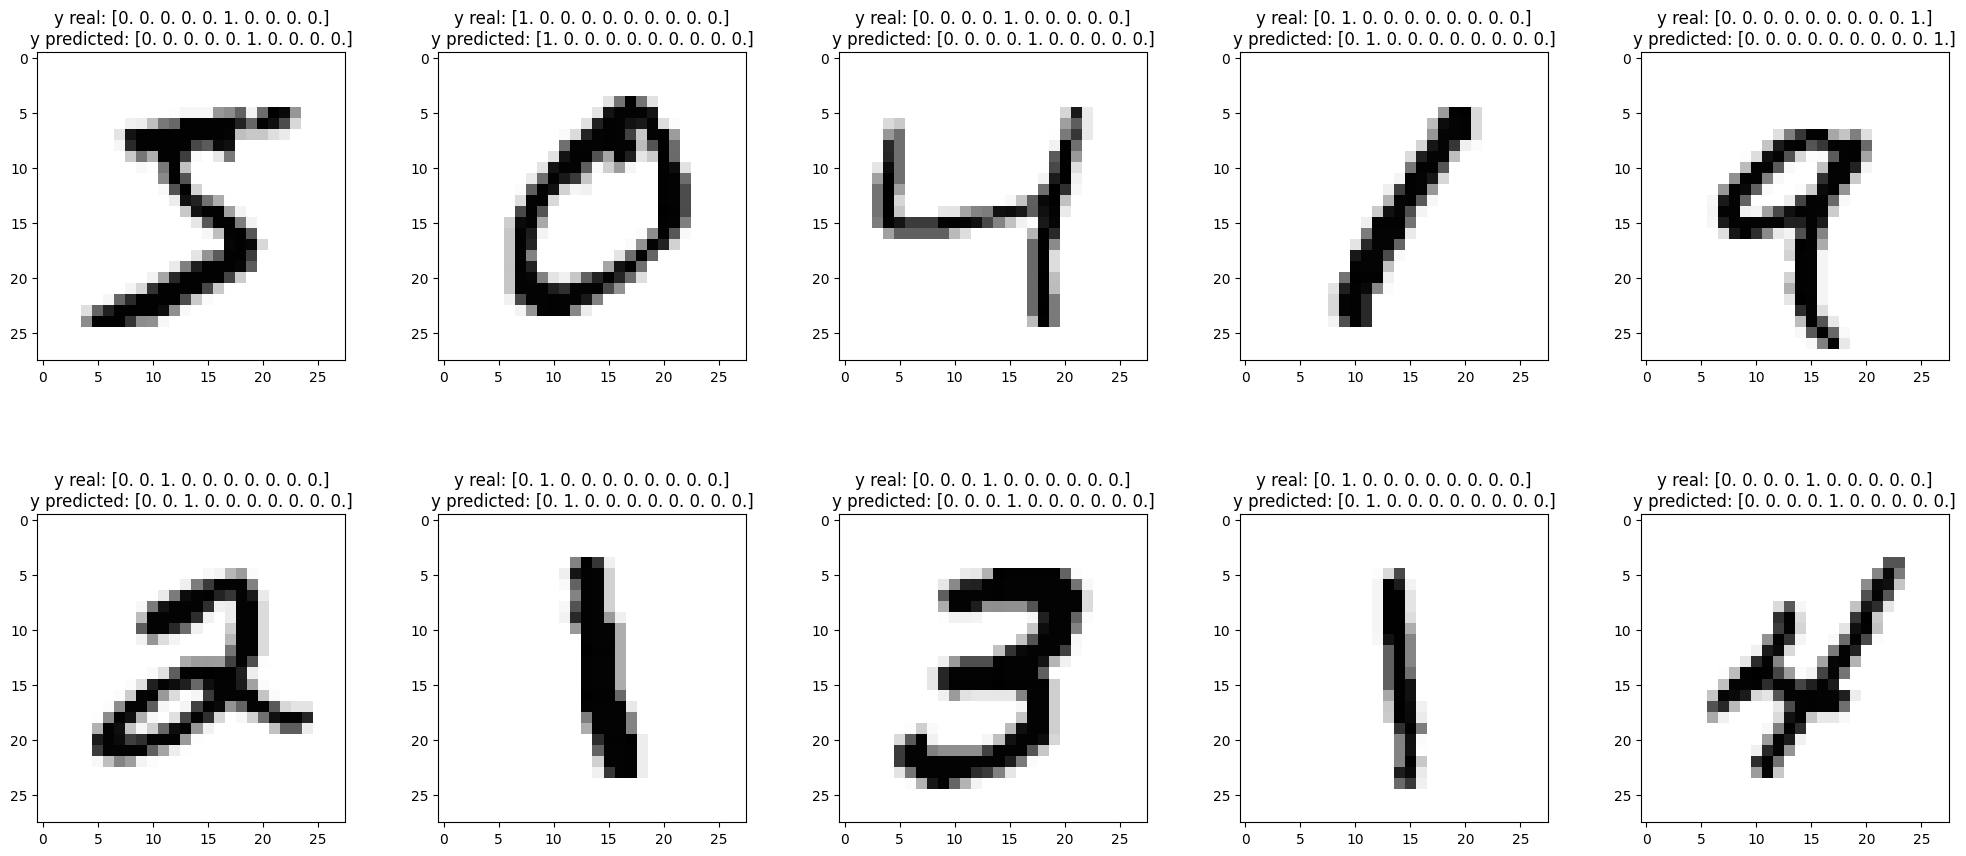

In [5]:
show_examples(X_train, y_train, y_train,num = 2)

# Model definition

In [6]:
def create_classifier():
    # Define the model with functional API
    # inputs = Input(shape=(28*28,))
    # x = Dense(128, activation='relu')(inputs)
    # x = Dense(64, activation='relu')(x)
    # x = Dense(32, activation='relu')(x)
    # outputs = Dense(10, activation='softmax')(x)

    # model = Model(inputs=inputs, outputs=outputs)

    model = Sequential([
        Dense(512, activation='leaky_relu', input_shape=(28*28,)),
        Dense(256, activation='relu'),
        Dense(20, activation='sigmoid'),
        Dense(10, activation='softmax')
    ]
    )

    
    return model

In [7]:
28 * 28 * 512 + 512

401920

In [8]:
model = create_classifier()
model.summary()
#plot_model(model, show_shapes=True, show_layer_names=False)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         5,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 538,598 (2.05 MB)

 Trainable params: 538,598 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model

In [10]:
history = model.fit(X_train_flatten, y_train, validation_split=0.2, epochs=40, verbose=1, batch_size=1024)

Epoch 1/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4979 - loss: 1.7961 - val_accuracy: 0.8882 - val_loss: 0.9508
Epoch 2/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8919 - loss: 0.8865 - val_accuracy: 0.9211 - val_loss: 0.6755
Epoch 3/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9231 - loss: 0.6392 - val_accuracy: 0.9373 - val_loss: 0.5249
Epoch 4/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9394 - loss: 0.4966 - val_accuracy: 0.9488 - val_loss: 0.4165
Epoch 5/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9508 - loss: 0.3955 - val_accuracy: 0.9549 - val_loss: 0.3432
Epoch 6/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9601 - loss: 0.3214 - val_accuracy: 0.9597 - val_loss: 0.2902
Epoch 7/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9657 - loss: 0.2667 - val_accuracy: 0.9628 - val_loss: 0.2523
Epoch 8/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9725 - loss: 0.2215 - val_accuracy: 0.9647 - val_l

# Evaluate the model

In [11]:
def plot_losses(history):
    plt.rcParams['figure.figsize'] = [20, 5]
    f, (ax1, ax2) = plt.subplots(1, 2, sharex=True)

    ax1.set_title('Losses')
    ax1.set_xlabel('epoch')
    ax1.legend(loc="upper right")
    ax1.grid()
    ax1.plot(history['loss'], label='Training loss')
    ax1.plot(history['val_loss'], label='Validation loss')
    ax1.legend()

    ax2.set_title('Accuracy')
    ax2.set_xlabel('epoch')
    ax2.legend(loc="upper right")
    ax2.grid()
    ax2.plot(history['accuracy'], label='Training accuracy')
    ax2.plot(history['val_accuracy'], label='Validation accuracy')
    ax2.legend()

    plt.show()

/var/folders/d8/d2bpzz691mdcd1j5dlc3wmcc0000gn/T/ipykernel_50085/217370305.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper right")
/var/folders/d8/d2bpzz691mdcd1j5dlc3wmcc0000gn/T/ipykernel_50085/217370305.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper right")


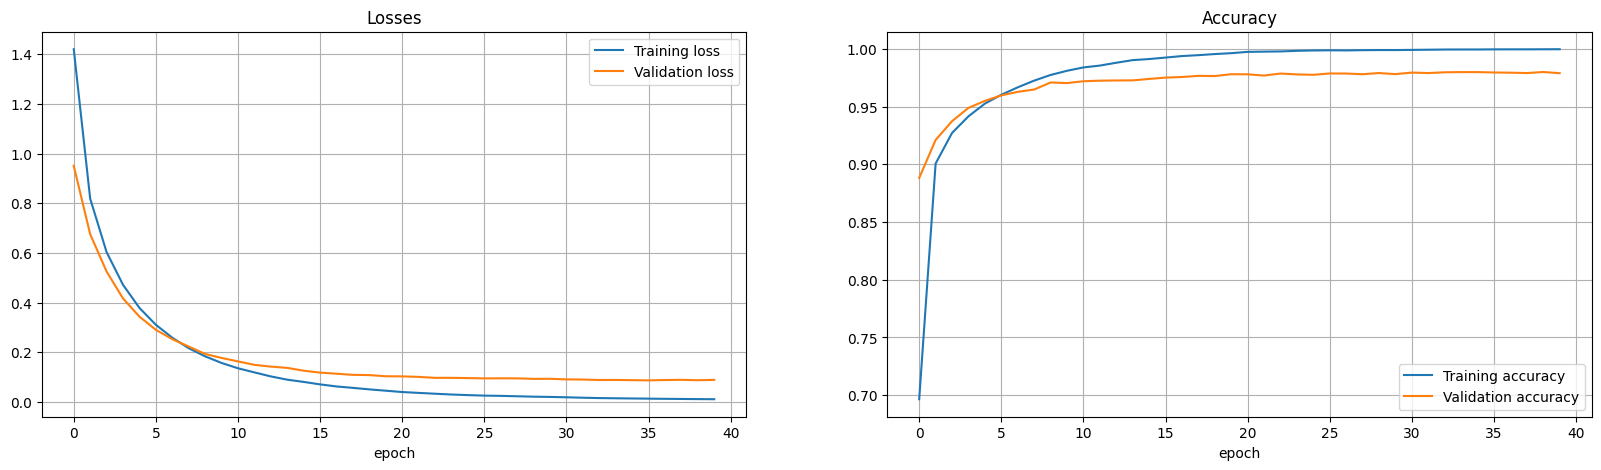

In [12]:
plot_losses(history.history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step


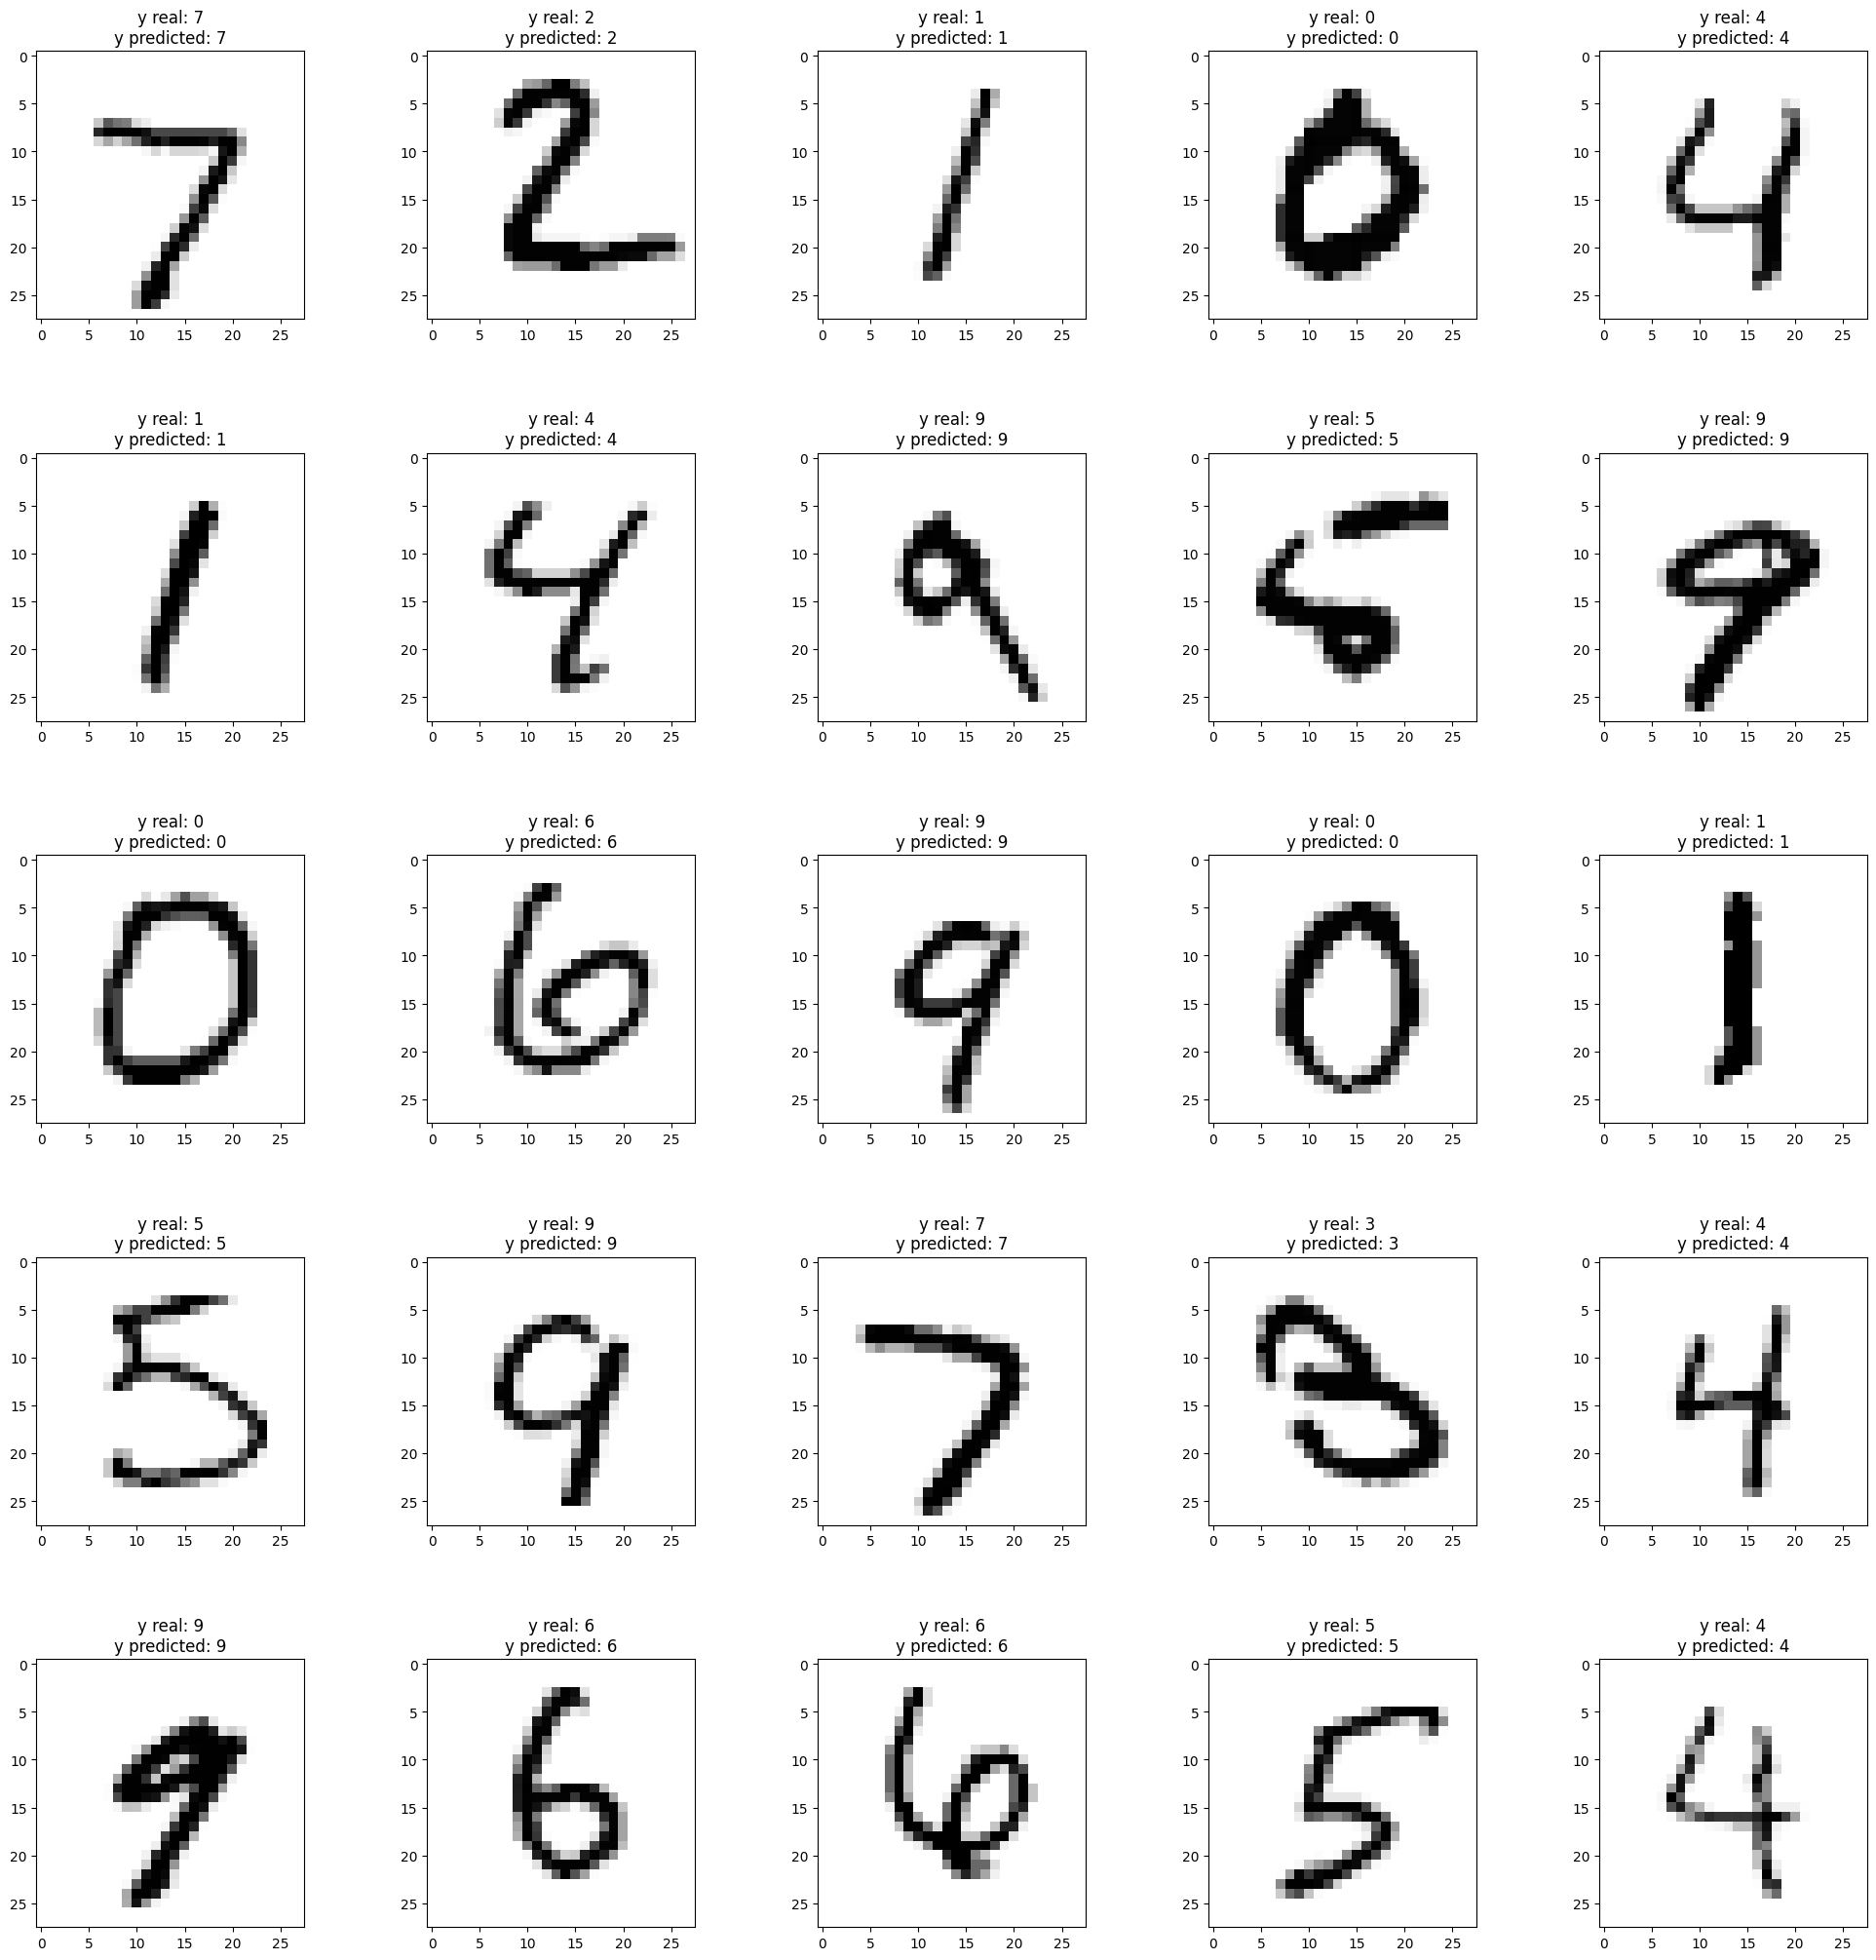

In [13]:
# Show prediction and the images predicted
y_pred = model.predict(X_test_flatten)
y_pred_classes = np.argmax(y_pred, axis=1)

show_examples(X_test, np.argmax(y_test, axis=1), y_pred_classes, num = 5)

---

Creado por **Guillermo Iglesias** (guillermo.iglesias@upm.es)

<img src="https://licensebuttons.net/l/by-nc-sa/3.0/88x31.png">